In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import scipy.stats as stats

# Load datasets
df_yearly = pd.read_csv('data/annual_deaths_by_clinic.csv')
df_monthly = pd.read_csv('data/monthly_deaths.csv')

# Convert the monthly date column to explicit Pandas Datetime objects
df_monthly['date'] = pd.to_datetime(df_monthly['date'])

print(f"Yearly Data Shape: {df_yearly.shape}")   # (12, 4)
print(f"Monthly Data Shape: {df_monthly.shape}") # (98, 3)

Yearly Data Shape: (12, 4)
Monthly Data Shape: (98, 3)


In [2]:
# 1. Calculate the percentage of deaths for each row in the yearly data
df_yearly['pct_deaths'] = (df_yearly.deaths / df_yearly.births) * 100

# 2. Compute the historical average death rate for each clinic
c1_total = df_yearly[df_yearly.clinic == 'clinic 1']
c2_total = df_yearly[df_yearly.clinic == 'clinic 2']

print(f"Average death rate in Clinic 1 (Doctors): {c1_total.deaths.sum() / c1_total.births.sum() * 100:.2f}%")
print(f"Average death rate in Clinic 2 (Midwives): {c2_total.deaths.sum() / c2_total.births.sum() * 100:.2f}%")

# 3. Visualize the comparison year-by-year
fig_clinic = px.line(
    df_yearly,
    x='year',
    y='pct_deaths',
    color='clinic',
    title='Maternal Death Proportion: Clinic 1 (Doctors) vs Clinic 2 (Midwives)'
)
fig_clinic.update_layout(yaxis_title='Percentage of Deaths (%)')
fig_clinic.show()

Average death rate in Clinic 1 (Doctors): 9.92%
Average death rate in Clinic 2 (Midwives): 3.88%


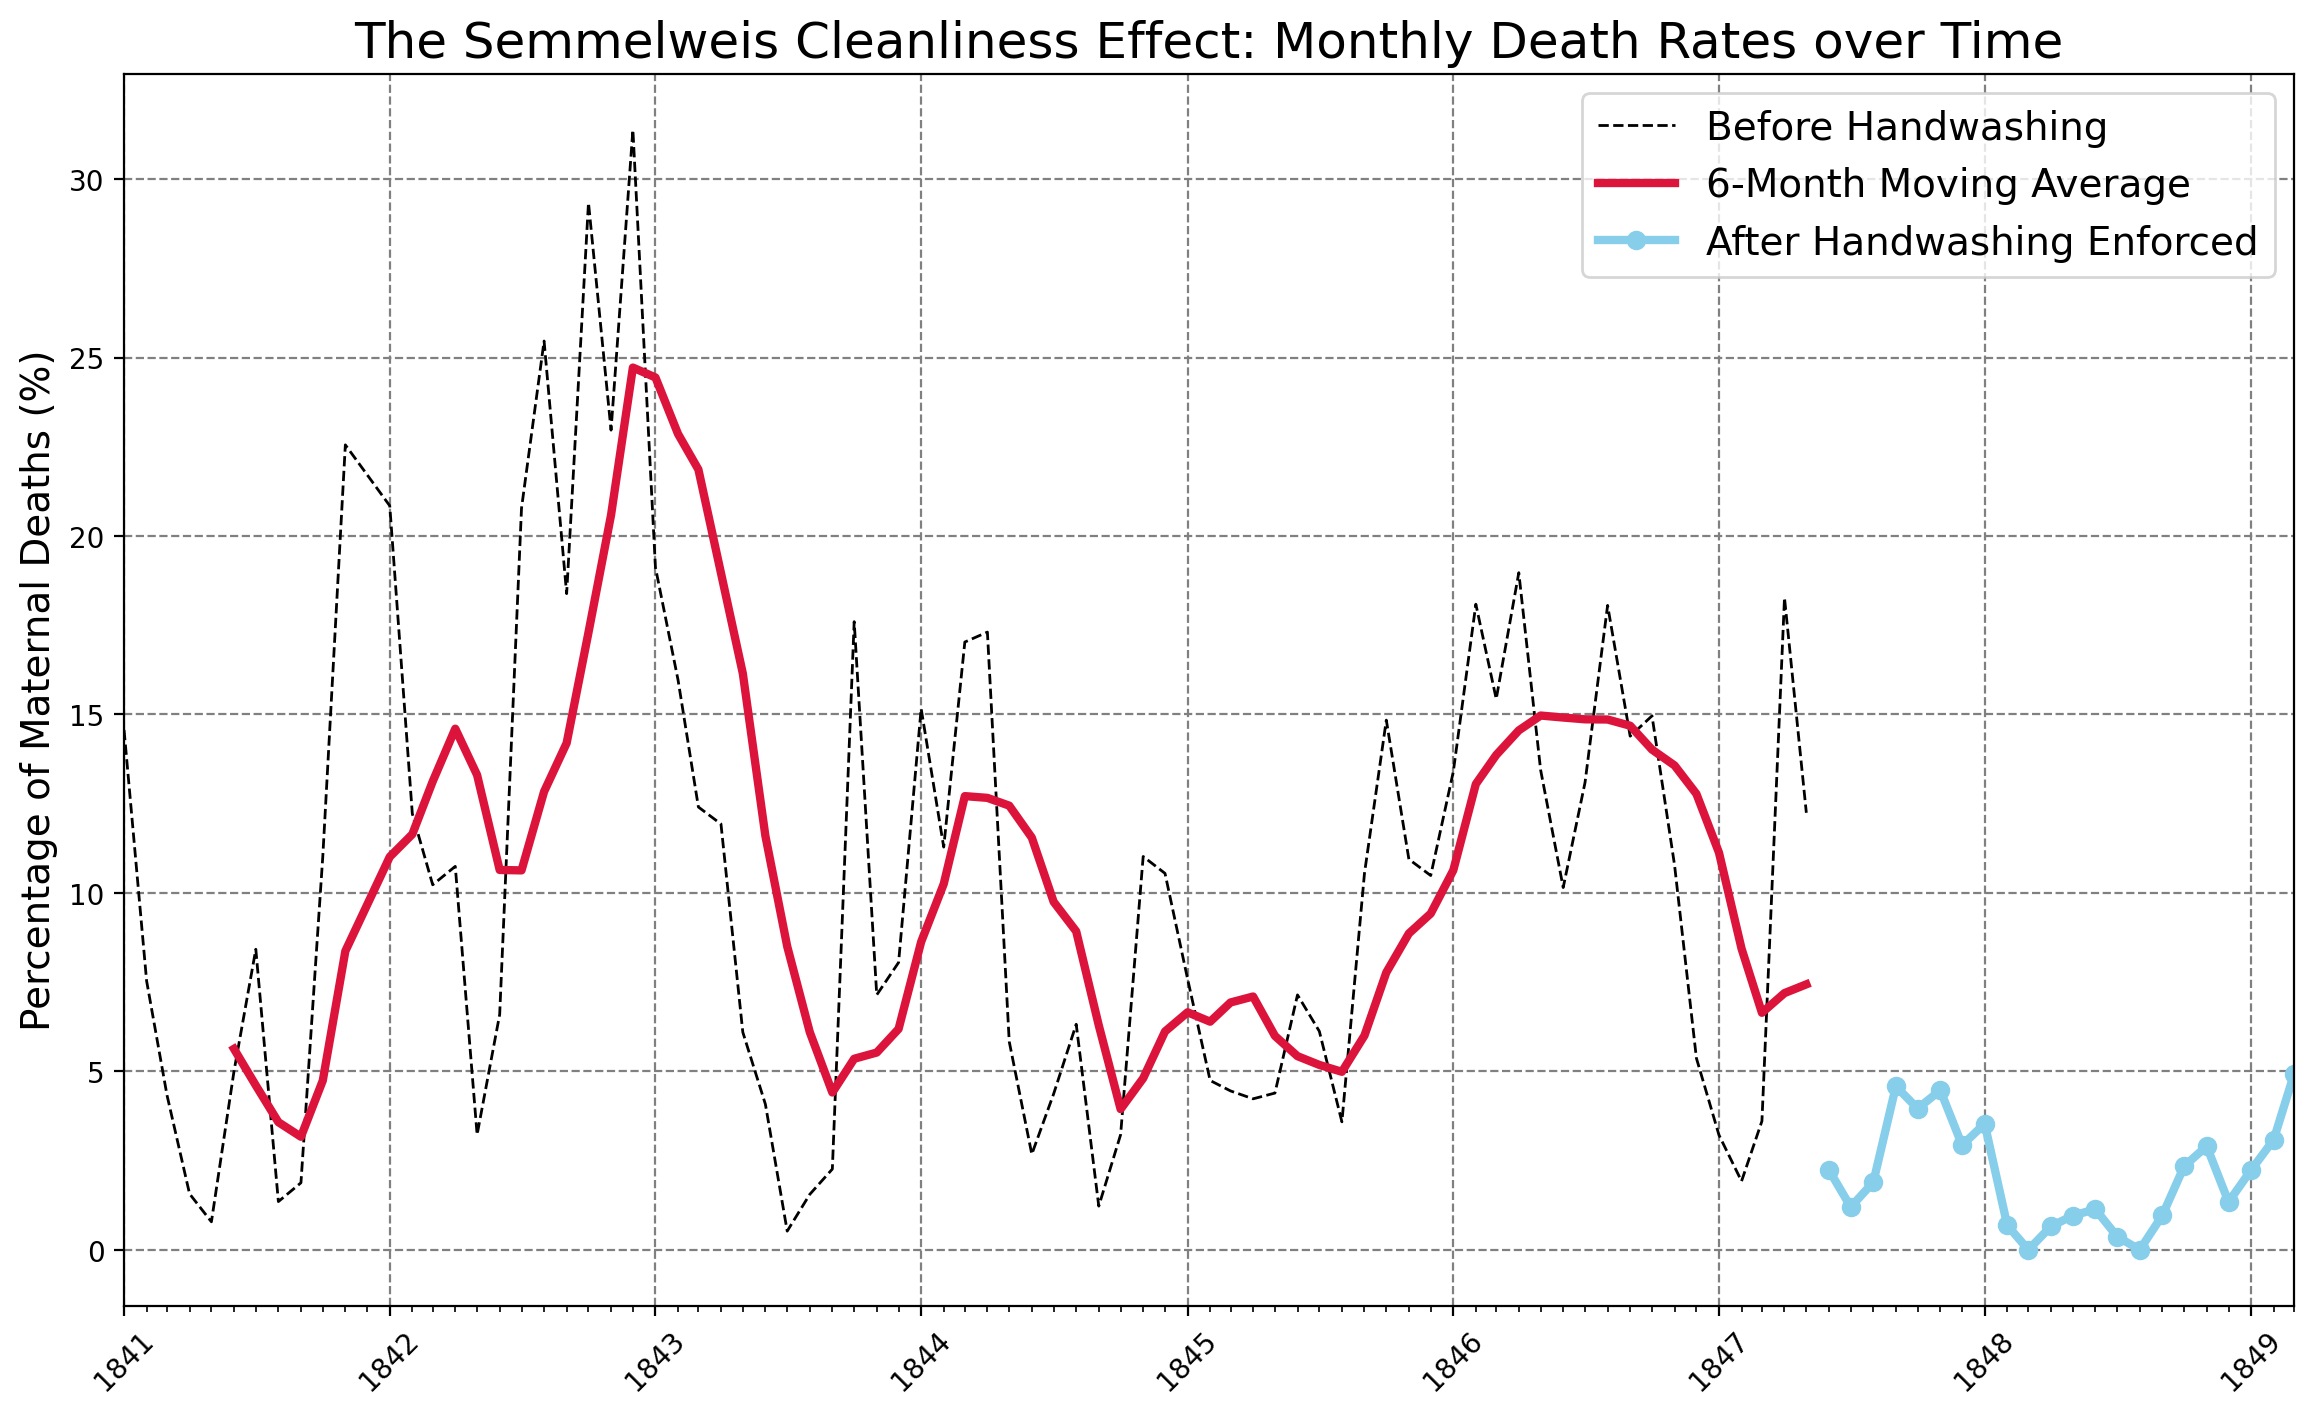

In [3]:
# Define the intervention milestone date
handwashing_start = pd.to_datetime('1847-06-01')

# 1. Engineer the monthly death percentage feature
df_monthly['pct_deaths'] = (df_monthly.deaths / df_monthly.births) * 100

# 2. Split the time series into experimental groups
before_washing = df_monthly[df_monthly.date < handwashing_start]
after_washing = df_monthly[df_monthly.date >= handwashing_start]

# 3. Calculate a 6-month rolling average for the pre-intervention era
roll_df = before_washing.set_index('date').rolling(window=6).mean()

# 4. Construct a highly stylized chart using explicit axis locators
plt.figure(figsize=(14, 8), dpi=200)
plt.title('The Semmelweis Cleanliness Effect: Monthly Death Rates over Time', fontsize=18)
plt.ylabel('Percentage of Maternal Deaths (%)', fontsize=14)
plt.grid(color='grey', linestyle='--')

ax = plt.gca()
ax.set_xlim([df_monthly.date.min(), df_monthly.date.max()])

# Apply date tickers
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator())

# Plot layers and assign handle names for the legend box
bw_line, = plt.plot(before_washing.date, before_washing.pct_deaths, color='black', linewidth=1, linestyle='--', label='Before Handwashing')
ma_line, = plt.plot(roll_df.index, roll_df.pct_deaths, color='crimson', linewidth=3, label='6-Month Moving Average')
aw_line, = plt.plot(after_washing.date, after_washing.pct_deaths, color='skyblue', linewidth=3, marker='o', label='After Handwashing Enforced')

plt.legend(handles=[bw_line, ma_line, aw_line], fontsize=14)
plt.xticks(rotation=45)
plt.show()

In [4]:
# Use NumPy's conditional switch function to tag rows cleanly
df_monthly['washing_hands'] = np.where(df_monthly.date < handwashing_start, 'No', 'Yes')

# Build the overlapping distribution frame
fig_hist = px.histogram(
    df_monthly,
    x='pct_deaths',
    color='washing_hands',
    nbins=30,
    opacity=0.6,
    barmode='overlay',
    histnorm='percent',
    marginal='box',
    title='Shift in Monthly Death Probability Distribution'
)

fig_hist.update_layout(xaxis_title='Proportion of Monthly Deaths (%)', yaxis_title='Percentage of Observations (%)')
fig_hist.show()

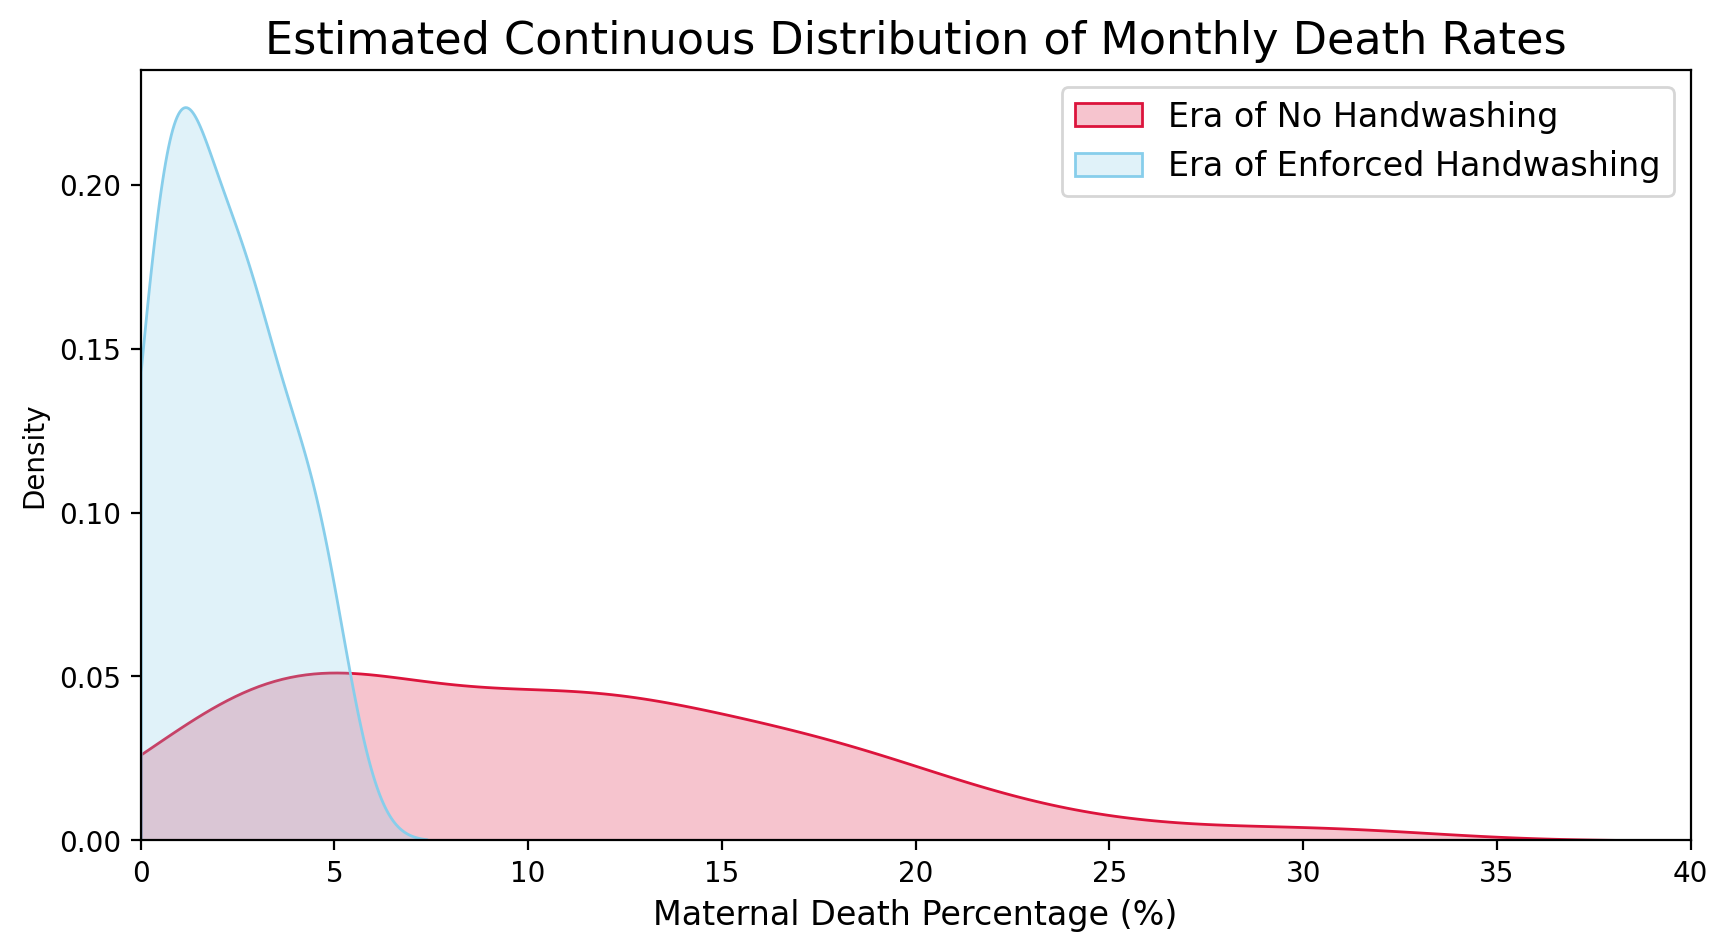

In [5]:
plt.figure(figsize=(10, 5), dpi=200)
plt.title('Estimated Continuous Distribution of Monthly Death Rates', fontsize=16)
plt.xlabel('Maternal Death Percentage (%)', fontsize=12)

# Fit smooth distribution models with clipped physics limits
sns.kdeplot(before_washing.pct_deaths, fill=True, color='crimson', clip=(0, 100), label='Era of No Handwashing')
sns.kdeplot(after_washing.pct_deaths, fill=True, color='skyblue', clip=(0, 100), label='Era of Enforced Handwashing')

plt.xlim(0, 40)
plt.legend(fontsize=12)
plt.show()

In [6]:
# Compute the t-statistic and the exact p-value
t_stat, p_value = stats.ttest_ind(a=before_washing.pct_deaths, b=after_washing.pct_deaths)

print("=== STATISTICAL INDEPENDENCE REPORT ===")
print(f"Calculated T-Statistic value: {t_stat:.4f}")
print(f"Calculated p-value score:     {p_value:.10f}")

if p_value < 0.01:
    print("\nCONCLUSION: The result is highly statistically significant at the 99% confidence level!")
    print("We safely reject the Null Hypothesis. Handwashing directly drops maternal mortality rates.")
else:
    print("\nCONCLUSION: Fail to reject the Null Hypothesis. Disparity could be due to random chance.")

=== STATISTICAL INDEPENDENCE REPORT ===
Calculated T-Statistic value: 5.5116
Calculated p-value score:     0.0000002985

CONCLUSION: The result is highly statistically significant at the 99% confidence level!
We safely reject the Null Hypothesis. Handwashing directly drops maternal mortality rates.
